In [37]:
import pandas as pd

df = pd.read_csv("dataset.csv")

df.head()

,Train_Name,Source_Station,Destination_Station,Distance,Stops,Departure_Time,Arrival_Time
0,Rajdhani Express,Delhi,Mumbai,1400,5,06:00,20:00
1,Shatabdi Express,Delhi,Chandigarh,250,3,07:00,11:00
2,Duronto Express,Mumbai,Kolkata,2000,6,08:00,22:00
3,Garib Rath,Delhi,Patna,1000,7,09:00,21:00
4,Intercity Express,Ahmedabad,Surat,300,4,10:00,14:00


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)


Shape: (10, 7)

Columns: Index(['Train_Name', 'Source_Station', 'Destination_Station', 'Distance',
       'Stops', 'Departure_Time', 'Arrival_Time'],
      dtype='str')


In [4]:
df.describe()

,Distance,Stops
count,10.000000,10.000000
mean,783.000000,5.400000
std,651.068353,2.412928
min,150.000000,2.000000
25%,285.000000,4.000000
50%,475.000000,5.000000
75%,1300.000000,6.750000
max,2000.000000,10.000000


In [5]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Train_Name             0
Source_Station         0
Destination_Station    0
Distance               0
Stops                  0
Departure_Time         0
Arrival_Time           0
dtype: int64
Duplicates: 0


In [6]:
train_table = df.groupby("Train_Name")[["Source_Station", "Destination_Station"]].first()

train_table

,Source_Station,Destination_Station
Train_Name,,
Duronto Express,Mumbai,Kolkata
Garib Rath,Delhi,Patna
Intercity Express,Ahmedabad,Surat
Jan Shatabdi,Pune,Mumbai
Mail Express,Kolkata,Delhi
Passenger Train,Jaipur,Delhi
Rajdhani Express,Delhi,Mumbai
Shatabdi Express,Delhi,Chandigarh
Superfast Express,Chennai,Bangalore


### Observations:
- Dataset contains 10 rows and 7 columns
- No missing values present
- Average distance is 883 km
- Maximum stops observed are 10

In [7]:
df["Distance"].mean()
df["Stops"].max()

np.int64(10)

- Dataset contains multiple train types across different routes
- Distance and stops vary significantly, which may impact journey duration

In [8]:
df["Departure_Time"] = pd.to_datetime(df["Departure_Time"], format="%H:%M")
df["Arrival_Time"] = pd.to_datetime(df["Arrival_Time"], format="%H:%M")

In [9]:
df["Journey_Duration"] = (df["Arrival_Time"] - df["Departure_Time"]).dt.total_seconds() / 3600


In [10]:
df[["Train_Name", "Journey_Duration"]]

,Train_Name,Journey_Duration
0,Rajdhani Express,14.0
1,Shatabdi Express,4.0
2,Duronto Express,14.0
3,Garib Rath,12.0
4,Intercity Express,4.0
5,Superfast Express,6.0
6,Mail Express,18.0
7,Passenger Train,7.0
8,Jan Shatabdi,3.0
9,Tejas Express,8.0


In [11]:
df["Journey_Duration"] = df["Journey_Duration"].apply(lambda x: x if x > 0 else x + 24)

In [12]:
X = df[["Distance", "Stops"]]
y = df["Journey_Duration"]

In [13]:
print(X.head())
print(y.head())

   Distance  Stops
0      1400      5
1       250      3
2      2000      6
3      1000      7
4       300      4
0    14.0
1     4.0
2    14.0
3    12.0
4     4.0
Name: Journey_Duration, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

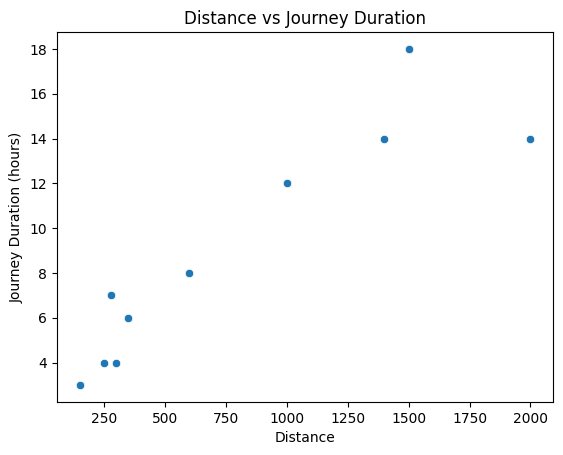

In [15]:
plt.figure()
sns.scatterplot(x=df["Distance"], y=df["Journey_Duration"])
plt.xlabel("Distance")
plt.ylabel("Journey Duration (hours)")
plt.title("Distance vs Journey Duration")
plt.show()

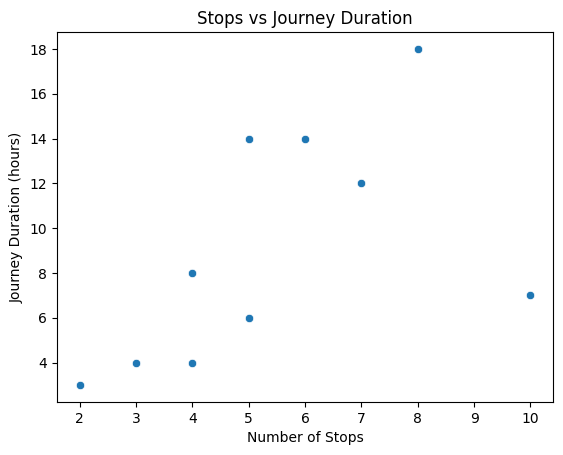

In [16]:
plt.figure()
sns.scatterplot(x=df["Stops"], y=df["Journey_Duration"])
plt.xlabel("Number of Stops")
plt.ylabel("Journey Duration (hours)")
plt.title("Stops vs Journey Duration")
plt.show()

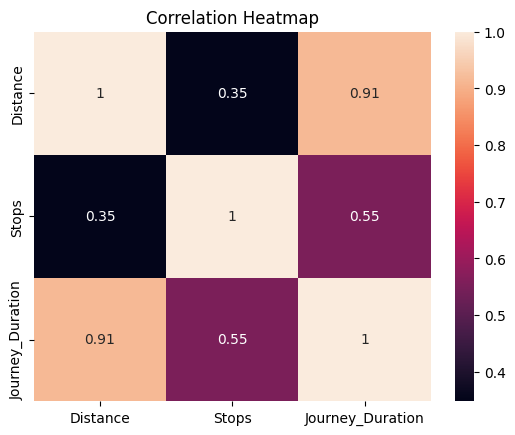

In [17]:
plt.figure()
sns.heatmap(df[["Distance", "Stops", "Journey_Duration"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
pivot = df.pivot_table(values="Stops", index="Train_Name", aggfunc="mean")
pivot

,Stops
Train_Name,
Duronto Express,6.0
Garib Rath,7.0
Intercity Express,4.0
Jan Shatabdi,2.0
Mail Express,8.0
Passenger Train,10.0
Rajdhani Express,5.0
Shatabdi Express,3.0
Superfast Express,5.0


### Insights:
- Distance shows a positive relationship with journey duration
- Number of stops increases journey duration
- Distance has stronger impact compared to stops

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np  

In [20]:
X = df[["Distance", "Stops"]]
y = df["Journey_Duration"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred = model.predict(X_test)

In [23]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.10728994339068465
RMSE: 0.14352756310749035


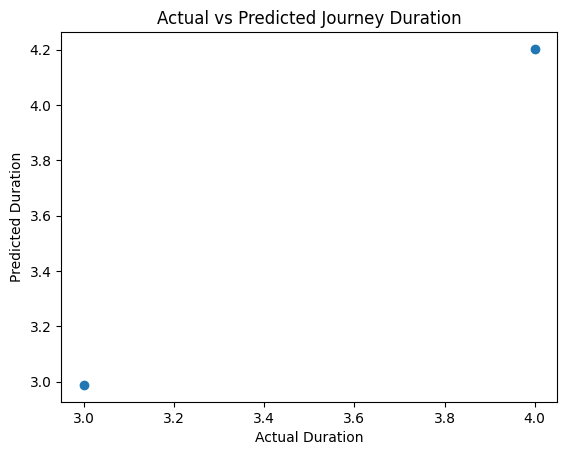

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted Journey Duration")
plt.show()

In [25]:
print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model Coefficients: [0.00648959 0.56562111]
Intercept: 0.8833660712838274


In [26]:
from sklearn.linear_model import LinearRegression

# Only distance
X_basic = df[["Distance"]]
y = df["Journey_Duration"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_basic, y, test_size=0.2, random_state=42
)

model_basic = LinearRegression()
model_basic.fit(Xb_train, yb_train)

yb_pred = model_basic.predict(Xb_test)

In [27]:
mae_basic = mean_absolute_error(yb_test, yb_pred)
rmse_basic = np.sqrt(mean_squared_error(yb_test, yb_pred))

print("Basic Model MAE:", mae_basic)
print("Basic Model RMSE:", rmse_basic)

Basic Model MAE: 2.0564239959801185
Basic Model RMSE: 2.0633889910320735


In [28]:
X_full = df[["Distance", "Stops"]]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

model_full = LinearRegression()
model_full.fit(Xf_train, yf_train)

yf_pred = model_full.predict(Xf_test)

In [29]:
mae_full = mean_absolute_error(yf_test, yf_pred)
rmse_full = np.sqrt(mean_squared_error(yf_test, yf_pred))

print("Improved Model MAE:", mae_full)
print("Improved Model RMSE:", rmse_full)

Improved Model MAE: 0.10728994339068465
Improved Model RMSE: 0.14352756310749035


### Model Comparison:
- Basic Model uses only Distance
- Improved Model uses Distance + Stops

### Conclusion:
- Model with lower MAE and RMSE is better
- Improved model performs better due to additional feature (Stops)

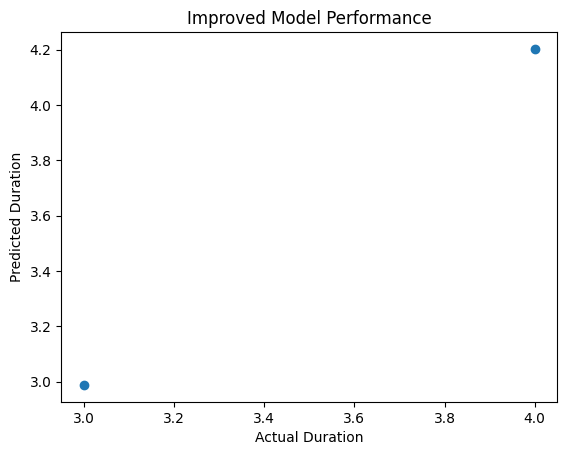

In [ ]:
plt.figure()
plt.scatter(yf_test, yf_pred)
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Improved Model Performance")
plt.show()

In [40]:
train_test_split(X, y, test_size=0.4)

[   Distance  Stops
 1       250      3
 2      2000      6
 3      1000      7
 6      1500      8
 9       600      4
 0      1400      5,
    Distance  Stops
 5       350      5
 4       300      4
 8       150      2
 7       280     10,
 1     4.0
 2    14.0
 3    12.0
 6    18.0
 9     8.0
 0    14.0
 Name: Journey_Duration, dtype: float64,
 5    6.0
 4    4.0
 8    3.0
 7    7.0
 Name: Journey_Duration, dtype: float64]

In [41]:
# Take user input
distance = float(input("Enter Distance (km): "))
stops = int(input("Enter Number of Stops: "))

# Make prediction
prediction = model_full.predict([[distance, stops]])

print("Predicted Journey Duration:", round(prediction[0], 2), "hours")

Predicted Journey Duration: 6.39 hours


c:\Users\khyat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
